# c3 Positive Analysis Summary

This notebook summarizes the consistency-score analysis for detecting `c3` positives from `data/classified_chatdev_scored`.

Final useful score from today's analysis:

```text
high_low_gap_0_9_0_5 = rate(turn_score >= 0.9) - rate(turn_score < 0.5)
```

For `c0` vs `c3`, lower values indicate stronger `c3` evidence. The best threshold found was:

```text
high_low_gap_0_9_0_5 <= -0.0714 => predict c3
```

Observed result on current data:

```text
eta^2 = 0.0653
F1    = 0.684
Recall = 0.844
Precision = 0.574
Accuracy = 0.638
```


In [2]:
from pathlib import Path
import csv
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
!pip install pandas
import pandas as pd

ROOT = Path('..').resolve()
VIS_DIR = ROOT / 'data' / 'classified_chatdev_scored' / '_visualizations'
FILE_RECORDS_CSV = VIS_DIR / 'consistency_file_records.csv'
C0_C3_SUMMARY_CSV = VIS_DIR / 'c0_vs_c3_eta2_f1_summary.csv'

file_records = pd.read_csv(FILE_RECORDS_CSV)
file_records.head()

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
     ----------- ---------------------------- 2.9/9.7 MB 14.0 MB/s eta 0:00:01
     ------------------------------ --------- 7.3/9.7 MB 18.1 MB/s eta 0:00:01
     ---------------------------------------- 9.7/9.7 MB 17.9 MB/s  0:00:00

   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   ---

,c2_coding_low05_rate,c2_low05_rate,c2_low_turn_avg_output_items,c2_low_turn_count,c2_max_low_run,c2_num_turns,c2_programmer_low05_rate,c2_repetition_symptom_score,c2_reviewmod_low05_rate,c2_score_std,...,num_roles,num_turns,raw_labels,source_files,strict_high_low_gap_0_9_0_5,user_demand,worst_phase,worst_role,worst_score,worst_turn
0,1.0,0.428571,5.166667,6.0,2.0,14.0,0.200000,-0.209003,0.000000,0.363671,...,5,14,0.0,0.0\ChatDev_ProgramDev2_GPT4o_0_scored.json,-0.142857,Create a CLI tool that takes a text file path ...,CodeReviewComment,Code Reviewer,4.070138e-03,2
1,0.0,0.307692,8.750000,4.0,2.0,13.0,0.166667,-0.514457,0.333333,0.347588,...,4,13,0.0,0.0\ChatDev_ProgramDev2_GPT4o_13_scored.json,0.000000,Create a CLI tool that displays a random quote...,DemandAnalysis,Chief Product Officer,2.784596e-07,2
2,0.0,0.230769,2.333333,3.0,2.0,13.0,0.200000,-0.813089,0.000000,0.346321,...,5,13,0.0,0.0\ChatDev_ProgramDev2_GPT4o_14_scored.json,0.307692,Develop a CLI utility to calculate and display...,CodeReviewComment,Code Reviewer,5.220126e-03,2
3,1.0,0.384615,6.400000,5.0,3.0,13.0,0.200000,-0.215431,0.000000,0.366917,...,5,13,0.0,0.0\ChatDev_ProgramDev2_GPT4o_16_scored.json,-0.153846,Write a CLI tool that fetches and displays the...,CodeReviewComment,Code Reviewer,2.075021e-05,2
4,1.0,0.611111,11.181818,11.0,5.0,18.0,0.625000,1.063861,1.000000,0.303136,...,5,18,0.0,0.0\ChatDev_ProgramDev2_GPT4o_1_scored.json,-0.388889,Develop a CLI utility that generates a visual ...,LanguageChoose,Chief Technology Officer,3.732688e-02,2


## Label Mapping Used in the Visualization Module

The visualizer maps raw labels to `c0..c4` before analysis:

| Display label | Raw labels |
|---|---|
| `c0` | `0.0` |
| `c1` | `1.1` |
| `c2` | `1.3`, `1.5` |
| `c3` | `2.2`, `2.3` |
| `c4` | `2.6` |

The current target is not all-class separation. The target is to detect `c3` positives, especially by comparing `c0` and `c3`.

In [3]:
label_counts = file_records['label'].value_counts().sort_index()
label_counts

label
c0    37
c1    32
c2    52
c3    32
c4    37
Name: count, dtype: int64

## Why the earlier c3-vs-rest setup was unstable

Many JSON files appear under multiple labels. If the same JSON appears both in `c3` and in a non-`c3` label, then feature-only classifiers receive identical file-level score features but contradictory labels.

When those conflicting JSONs were removed, only 3 clean `c3` positives remained. That made threshold selection too unstable. Therefore, the analysis pivoted to a cleaner comparison: `c0` vs `c3`.

In [4]:
by_file = defaultdict(list)
for row in file_records.to_dict('records'):
    by_file[row['file_name']].append(row['label'])

conflict_files = {
    file_name
    for file_name, labels in by_file.items()
    if 'c3' in labels and any(label != 'c3' for label in labels)
}

clean_records = file_records[~file_records['file_name'].isin(conflict_files)]

print('Total label-file records:', len(file_records))
print('Unique JSON files:', len(by_file))
print('c3/non-c3 conflict JSON files:', len(conflict_files))
print('Clean label-file records:', len(clean_records))
print('\nClean label counts:')
print(clean_records['label'].value_counts().sort_index())

Total label-file records: 190
Unique JSON files: 116
c3/non-c3 conflict JSON files: 29
Clean label-file records: 106

Clean label counts:
label
c0    37
c1    18
c2    29
c3     3
c4    19
Name: count, dtype: int64


## c0 vs c3: Best Single Evaluation Score

After trying many file-level evaluation scores, the best single score for `c0` vs `c3` was:

```text
high_low_gap_0_9_0_5 = rate(score >= 0.9) - rate(score < 0.5)
```

Interpretation:

- `c0` tends to have more very-high-confidence turns and fewer low turns.
- `c3` tends to have fewer `>=0.9` turns and/or more `<0.5` turns.
- Therefore lower `high_low_gap_0_9_0_5` values are more `c3`-like.


In [5]:
summary = pd.read_csv(C0_C3_SUMMARY_CSV)
summary.sort_values(['f1', 'eta2'], ascending=False).head(15)

,score_key,eta2,f1,accuracy,precision,recall,specificity,direction,threshold,tp,fp,tn,fn,c3_mean,c0_mean
0,high_low_gap_0_9_0_5,0.065288,0.683544,0.637681,0.574468,0.84375,0.459459,low_is_c3,0.071429,27,20,17,5,-0.102468,0.002494
1,strict_high_low_gap_0_9_0_5,0.065288,0.683544,0.637681,0.574468,0.84375,0.459459,low_is_c3,0.071429,27,20,17,5,-0.102468,0.002494
2,c2_repetition_symptom_score,0.013308,0.682353,0.608696,0.547170,0.90625,0.351351,high_is_c3,-0.431617,29,24,13,3,0.048373,-0.092509
3,high_low_half_penalty_0_9_0_5,0.061569,0.676471,0.681159,0.638889,0.71875,0.648649,low_is_c3,0.117647,23,13,24,9,0.080084,0.156361
4,consistency_score_file_q25,0.026701,0.674419,0.594203,0.537037,0.90625,0.324324,low_is_c3,0.541030,29,25,12,3,0.338034,0.401424
5,c2_low_turn_avg_output_items,0.006517,0.673913,0.565217,0.516667,0.96875,0.216216,low_is_c3,18.750000,31,29,8,1,10.902939,12.015425
6,high_density_score_0_8,0.037396,0.666667,0.623188,0.565217,0.81250,0.459459,low_is_c3,0.261742,26,20,17,6,0.215419,0.262823
7,c2_score_std,0.000069,0.666667,0.550725,0.508197,0.96875,0.189189,low_is_c3,0.385130,31,30,7,1,0.332522,0.333405
8,consistency_score_file_std,0.000069,0.666667,0.550725,0.508197,0.96875,0.189189,low_is_c3,0.385130,31,30,7,1,0.332522,0.333405
9,low_score_rate_0_8,0.049501,0.666667,0.608696,0.551020,0.84375,0.405405,high_is_c3,0.571429,27,22,15,5,0.655198,0.592087


In [6]:
best_key = 'high_low_gap_0_9_0_5'
c0_c3 = file_records[file_records['label'].isin(['c0', 'c3'])].copy()
c0_c3['is_c3'] = (c0_c3['label'] == 'c3').astype(int)

best_row = summary[summary['score_key'] == best_key].iloc[0]
threshold = float(best_row['threshold'])
direction = best_row['direction']

if direction == 'low_is_c3':
    pred = c0_c3[best_key] <= threshold
else:
    pred = c0_c3[best_key] >= threshold

tp = int(((pred) & (c0_c3['is_c3'] == 1)).sum())
fp = int(((pred) & (c0_c3['is_c3'] == 0)).sum())
tn = int(((~pred) & (c0_c3['is_c3'] == 0)).sum())
fn = int(((~pred) & (c0_c3['is_c3'] == 1)).sum())

precision = tp / (tp + fp) if tp + fp else 0.0
recall = tp / (tp + fn) if tp + fn else 0.0
f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
accuracy = (tp + tn) / len(c0_c3)

metrics = {
    'score_key': best_key,
    'direction': direction,
    'threshold': threshold,
    'eta2': float(best_row['eta2']),
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'tp': tp,
    'fp': fp,
    'tn': tn,
    'fn': fn,
}
metrics

{'score_key': 'high_low_gap_0_9_0_5',
 'direction': 'low_is_c3',
 'threshold': 0.0714285714285714,
 'eta2': 0.0652880028960246,
 'accuracy': 0.6376811594202898,
 'precision': 0.574468085106383,
 'recall': 0.84375,
 'f1': 0.6835443037974684,
 'tp': 27,
 'fp': 20,
 'tn': 17,
 'fn': 5}

## Plot: c0 vs c3 distribution

The plot below uses a `c3`-oriented version of the score:

```text
c3_score = -high_low_gap_0_9_0_5
```

So higher values indicate stronger `c3` evidence.

C:\Users\Aurora\AppData\Local\Temp\ipykernel_17076\2669092349.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([c0_values, c3_values], labels=['c0', 'c3'], showmeans=True, patch_artist=True)


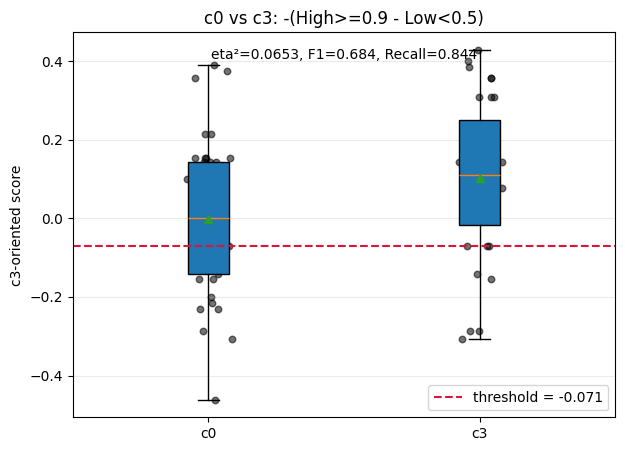

In [7]:
rng = np.random.default_rng(20260504)
c0_values = -c0_c3.loc[c0_c3['label'] == 'c0', best_key].to_numpy()
c3_values = -c0_c3.loc[c0_c3['label'] == 'c3', best_key].to_numpy()
oriented_threshold = -threshold

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([c0_values, c3_values], labels=['c0', 'c3'], showmeans=True, patch_artist=True)
for idx, values in enumerate([c0_values, c3_values], start=1):
    ax.scatter(rng.normal(idx, 0.035, len(values)), values, color='black', s=22, alpha=0.55)

ax.axhline(oriented_threshold, color='crimson', linestyle='--', linewidth=1.5, label=f'threshold = {oriented_threshold:.3f}')
ax.set_title('c0 vs c3: -(High>=0.9 - Low<0.5)')
ax.set_ylabel('c3-oriented score')
ax.text(0.5, 0.96, f"eta²={metrics['eta2']:.4f}, F1={metrics['f1']:.3f}, Recall={metrics['recall']:.3f}", transform=ax.transAxes, ha='center', va='top')
ax.grid(axis='y', alpha=0.25)
ax.legend()
plt.show()

## Eta² vs F1: why they differ

`eta²` and `F1` measure different things:

- `eta²` measures how much of the total score variance is explained by group membership. If the two boxplots overlap heavily, `eta²` remains modest.
- `F1` measures threshold classification quality. A threshold can capture many positives even when the distributions overlap.

For `high_low_gap_0_9_0_5`, the two groups still overlap, so `eta²=0.0653` is not huge. But the threshold catches 27 of 32 c3 samples, giving `recall=0.844` and `F1=0.684`.

In [8]:
top_by_f1 = summary.sort_values(['f1', 'eta2'], ascending=False).head(10)
top_by_eta2 = summary.sort_values(['eta2', 'f1'], ascending=False).head(10)

display(top_by_f1[['score_key', 'eta2', 'f1', 'precision', 'recall', 'accuracy', 'direction', 'threshold']])
display(top_by_eta2[['score_key', 'eta2', 'f1', 'precision', 'recall', 'accuracy', 'direction', 'threshold']])

,score_key,eta2,f1,precision,recall,accuracy,direction,threshold
0,high_low_gap_0_9_0_5,0.065288,0.683544,0.574468,0.84375,0.637681,low_is_c3,0.071429
1,strict_high_low_gap_0_9_0_5,0.065288,0.683544,0.574468,0.84375,0.637681,low_is_c3,0.071429
2,c2_repetition_symptom_score,0.013308,0.682353,0.547170,0.90625,0.608696,high_is_c3,-0.431617
3,high_low_half_penalty_0_9_0_5,0.061569,0.676471,0.638889,0.71875,0.681159,low_is_c3,0.117647
4,consistency_score_file_q25,0.026701,0.674419,0.537037,0.90625,0.594203,low_is_c3,0.541030
5,c2_low_turn_avg_output_items,0.006517,0.673913,0.516667,0.96875,0.565217,low_is_c3,18.750000
6,high_density_score_0_8,0.037396,0.666667,0.565217,0.81250,0.623188,low_is_c3,0.261742
7,c2_score_std,0.000069,0.666667,0.508197,0.96875,0.550725,low_is_c3,0.385130
8,consistency_score_file_std,0.000069,0.666667,0.508197,0.96875,0.550725,low_is_c3,0.385130
9,low_score_rate_0_8,0.049501,0.666667,0.551020,0.84375,0.608696,high_is_c3,0.571429


,score_key,eta2,f1,precision,recall,accuracy,direction,threshold
66,c2_coding_low05_rate,0.076823,0.633663,0.463768,1.00000,0.463768,high_is_c3,0.000000
53,c2_max_low_run,0.070360,0.640000,0.470588,1.00000,0.478261,high_is_c3,1.000000
0,high_low_gap_0_9_0_5,0.065288,0.683544,0.574468,0.84375,0.637681,low_is_c3,0.071429
1,strict_high_low_gap_0_9_0_5,0.065288,0.683544,0.574468,0.84375,0.637681,low_is_c3,0.071429
30,high_low_gap_0_8_0_5,0.062748,0.650000,0.541667,0.81250,0.594203,low_is_c3,0.142857
3,high_low_half_penalty_0_9_0_5,0.061569,0.676471,0.638889,0.71875,0.681159,low_is_c3,0.117647
48,high_low_half_penalty_0_8_0_5,0.061133,0.642857,0.519231,0.84375,0.565217,low_is_c3,0.285714
54,consistency_score_file_q75,0.058807,0.640000,0.470588,1.00000,0.478261,low_is_c3,0.999974
27,high_low_half_penalty_0_8_0_2,0.053413,0.651163,0.518519,0.87500,0.565217,low_is_c3,0.357143
65,high_low_gap_0_8_0_2,0.051576,0.635294,0.509434,0.84375,0.550725,low_is_c3,0.285714


## Final Takeaways

1. Five-way separation among `c0..c4` is weak using only consistency scores.
2. `c3` vs all non-`c3` is complicated by multi-label JSON conflicts.
3. Removing conflict files leaves too few clean `c3` positives, so threshold estimates become unstable.
4. `c0` vs `c3` is a cleaner comparison and produces a useful single score.
5. The best simple score is `high_low_gap_0_9_0_5`, with `eta²=0.0653` and `F1=0.684`.

Recommended reporting rule:

```text
Predict c3 if rate(score >= 0.9) - rate(score < 0.5) <= -0.0714
```

This is interpretable: c3 is characterized by fewer extremely confident turns and more low-consistency turns.